In [1]:
from transformers import BertTokenizerFast, BertModel
from transformers import RobertaTokenizerFast, RobertaModel
import spacy
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import torch
import os

In [2]:
from data import *
from model import *
from utilsv2 import *
from analysis_topk import *

In [3]:
os.environ["TOKENIZERS_PARALLELISM"] = "true"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Khởi tạo tokenizer và model BERT
tokenizer_bert = BertTokenizerFast.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")

# --- Khởi tạo RoBERTa ---
# tokenizer_bert = RobertaTokenizerFast.from_pretrained("roberta-base")
# bert = RobertaModel.from_pretrained("roberta-base")

# Thêm token đặc biệt nếu chưa có
special_tokens = {"additional_special_tokens": ["[E1]", "[/E1]", "[E2]", "[/E2]"]}
num_added_toks = tokenizer_bert.add_special_tokens(special_tokens)
bert.resize_token_embeddings(len(tokenizer_bert))  # Resize embedding BERT


# Tokenizer và DataLoader
spacy_nlp = spacy.load('en_core_web_sm')
spacy_nlp.tokenizer = create_custom_tokenizer(spacy_nlp, special_tokens['additional_special_tokens'])

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [5]:
data_source = "/data/ddao/TRE/data/raw_data/TBD/processed/"
data_train_path = data_source + "train.csv"
data_valid_path = data_source + "dev.csv"
data_test_path = data_source + "test.csv"

train_df = pd.read_csv(data_train_path)
valid_df = pd.read_csv(data_valid_path)
test_df = pd.read_csv(data_test_path)

# Mã hóa nhãn
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
valid_df['label_encoded'] = label_encoder.fit_transform(valid_df['label'])
test_df['label_encoded'] = label_encoder.transform(test_df['label'])  # Ánh xạ giống tập huấn luyện

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Label Mapping: {label_mapping}")

relations = list(label_mapping.keys())

print("train_df:", train_df.shape)
print("valid_df:", valid_df.shape)
print("test_df:", test_df.shape)

Label Mapping: {'AFTER': 0, 'BEFORE': 1, 'INCLUDES': 2, 'IS_INCLUDED': 3, 'SIMULTANEOUS': 4, 'VAGUE': 5}
train_df: (4032, 12)
valid_df: (629, 12)
test_df: (1427, 12)


In [6]:
# --- Thống kê số lượng quan hệ trong từng tập ---
def count_relations(df, name="Dataset"):
    counts = df['label'].value_counts().sort_index()
    percents = (counts / len(df) * 100).round(2)
    stats_df = pd.DataFrame({
        'Relation': counts.index,
        f'{name} Count': counts.values,
        f'{name} %': percents.values
    })
    return stats_df

# Gộp kết quả ba tập thành một bảng duy nhất
train_stats = count_relations(train_df, "Train")
valid_stats = count_relations(valid_df, "Valid")
test_stats  = count_relations(test_df, "Test")

# Gộp tất cả vào một bảng chung (theo cột Relation)
summary_df = train_stats.merge(valid_stats, on="Relation", how="outer") \
                        .merge(test_stats, on="Relation", how="outer") \
                        .fillna(0)

# Thêm tổng cộng cho từng loại quan hệ
summary_df["Total Count"] = summary_df["Train Count"] + summary_df["Valid Count"] + summary_df["Test Count"]
summary_df["Total %"] = (summary_df["Total Count"] / summary_df["Total Count"].sum() * 100).round(2)

print("\n📊 Relation Statistics (MATRES):\n")
print(summary_df.to_string(index=False))


📊 Relation Statistics (MATRES):

    Relation  Train Count  Train %  Valid Count  Valid %  Test Count  Test %  Total Count  Total %
       AFTER          674    16.72          172    27.34         274   19.20         1120    18.40
      BEFORE          808    20.04          156    24.80         384   26.91         1348    22.14
    INCLUDES          206     5.11           14     2.23          56    3.92          276     4.53
 IS_INCLUDED          273     6.77           21     3.34          53    3.71          347     5.70
SIMULTANEOUS           59     1.46           12     1.91          22    1.54           93     1.53
       VAGUE         2012    49.90          254    40.38         638   44.71         2904    47.70


In [7]:

# # ✅ Loại bỏ nhãn VAGUE khỏi cả train, valid, test
# train_df = train_df[train_df['label'] != 'VAGUE'].reset_index(drop=True)
# valid_df = valid_df[valid_df['label'] != 'VAGUE'].reset_index(drop=True)
# test_df = test_df[test_df['label'] != 'VAGUE'].reset_index(drop=True)

# print("Sau khi loại bỏ VAGUE:")
# print(f"  train_df: {train_df.shape}")
# print(f"  valid_df: {valid_df.shape}")
# print(f"  test_df:  {test_df.shape}")

# # ✅ Mã hóa nhãn sau khi lọc
# label_encoder = LabelEncoder()
# train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
# valid_df['label_encoded'] = label_encoder.transform(valid_df['label'])
# test_df['label_encoded'] = label_encoder.transform(test_df['label'])

# # In mapping
# label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# print(f"Label Mapping: {label_mapping}")

# relations = list(label_mapping.keys())
# print(f"Relations used for training: {relations}")

In [8]:
print("Create dataloader:")
batch_size = 128
window_size = 128
MAX_LENGTH = 256
shuffle=False
print("batch_size: ", batch_size)
print("window_size: ", window_size)
print("MAX_LENGTH: ", MAX_LENGTH)

Create dataloader:
batch_size:  128
window_size:  128
MAX_LENGTH:  256


In [9]:
# train_dataloader = create_dataloader(train_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TBD=True)
# validation_dataloader = create_dataloader(valid_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TBD=True)
# test_dataloader = create_dataloader(test_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_TBD=True)

In [10]:
# train_dataloader_path =  f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/train_dataloader_ws_{window_size}_no_vague.pt"
# validation_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/validation_dataloader_ws_{window_size}_no_vague.pt"
# test_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_dataloader_ws_{window_size}_no_vague.pt"

train_dataloader_path =  f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/train_dataloader_ws_{window_size}.pt"
validation_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/validation_dataloader_ws_{window_size}.pt"
test_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_dataloader_ws_{window_size}.pt"

# train_dataloader_path =  f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/train_dataloader_ws_{window_size}_RoBERTa.pt"
# validation_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/validation_dataloader_ws_{window_size}_RoBERTa.pt"
# test_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_dataloader_ws_{window_size}_RoBERTa.pt"

In [11]:
# torch.save(train_dataloader, train_dataloader_path)
# torch.save(validation_dataloader, validation_dataloader_path)
# torch.save(test_dataloader, test_dataloader_path)

In [12]:
train_dataloader = torch.load(train_dataloader_path)
validation_dataloader = torch.load(validation_dataloader_path)
test_dataloader = torch.load(test_dataloader_path)

In [13]:
# ============================================================
# Hyperparameters
# ============================================================
hidden_ffn_dim   = 512
num_heads        = 8
num_layers       = 1
dropout          = 0.3
num_classes      = len(label_encoder.classes_)

num_epochs       = 30
eval_step        = 1
LEARNING_RATE    = 1e-5

top_k            = 10

vague_label_id = label_encoder.transform(["VAGUE"])[0]
print(f"hidden_ffn_dim: {hidden_ffn_dim}")
print(f"num_layers: {num_layers}")
print(f"num_heads: {num_heads}")
print(f"top_k: {top_k}")
print(f"num_classes: {num_classes}")
print(f"vague_label_id: {vague_label_id}")
# ============================================================
# Save path
# ============================================================

save_path = (
    f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/"
    f"FTBERT_TBD_MHA_{num_layers}_FFN_{hidden_ffn_dim}_TOP_{top_k}.pth"
)

# save_path = (
#     f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/"
#     f"FTRoBERTa_TBD_MHA_{num_layers}_FFN_{hidden_ffn_dim}_TOP_{top_k}.pth"
# )
print('Model will save at:', save_path)

hidden_ffn_dim: 512
num_layers: 1
num_heads: 8
top_k: 10
num_classes: 6
vague_label_id: 5
Model will save at: /data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/FTBERT_TBD_MHA_1_FFN_512_TOP_10.pth


In [14]:
print("\nCreate model:")
model = TemporalRelationModelV2(
    bert=bert,
    tokenizer=tokenizer_bert,
    hidden_ffn_dim=hidden_ffn_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
    num_classes=num_classes,
    device=device
).to(device)

print("Device:", device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("--" * 20)


Create model:
Device: cuda
----------------------------------------


/home/prof/ddao/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [15]:
# print("\nStart Training...")
# losses = train_model(
#     model=model,
#     top_k=top_k,
#     train_dataloader=train_dataloader,
#     validation_dataloader=validation_dataloader,
#     optimizer=optimizer,
#     criterion=criterion,
#     device=device,
#     num_epochs=num_epochs,
#     save_path=save_path,
#     eval_step=eval_step,
#     max_grad_norm=1.0,      # clip grad
#     lambda_aux=1.0,         # weight cho aux loss (0 nếu không dùng)
#     is_TBD=True,
#     vague_label_id=vague_label_id
# )

# Evaluate

In [16]:
print("Load pretrained model:")
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Model saved at epoch {epoch}, loss = {loss:.4f}")

Load pretrained model:
Model saved at epoch 29, loss = 0.0146


In [15]:
def grip_search(data_loader, model, K):
    metrics_by_topk = []
    for k in range(0,K+1,1):
        cm, f1, p, r, precisions,recalls, f1s = evaluate(data_loader,
                                                        model=model,
                                                        top_k=k,
                                                        device=device,
                                                        return_preds=False,
                                                        is_TBD=True, 
                                                        vague_label_id=vague_label_id
                                                        )
        metrics_by_topk.append([k,
                                round(f1, 4),
                                round(p, 4),
                                round(r, 4)
                            ])
        print(f"top_K: {k} - F1: {f1:.4f} | Precision: {p:.4f} | Recall: {r:.4f}")
        print()
    return metrics_by_topk

In [16]:
metrics_by_topk = grip_search(test_dataloader, model, 20)

Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.81it/s]


Evaluation finished in 6.64s.
Filtered 638/1427 (44.71%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8150, F1=0.8150, P=0.8150, R=0.8150
top_K: 0 - F1: 0.8150 | Precision: 0.8150 | Recall: 0.8150



Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.95it/s]


Evaluation finished in 6.14s.
Filtered 638/1427 (44.71%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8150, F1=0.8150, P=0.8150, R=0.8150
top_K: 1 - F1: 0.8150 | Precision: 0.8150 | Recall: 0.8150



Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.95it/s]


...

Evaluation finished in 6.35s.
Filtered 638/1427 (44.71%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8276, F1=0.8276, P=0.8276, R=0.8276
top_K: 18 - F1: 0.8276 | Precision: 0.8276 | Recall: 0.8276



Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.89it/s]


Evaluation finished in 6.36s.
Filtered 638/1427 (44.71%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8264, F1=0.8264, P=0.8264, R=0.8264
top_K: 19 - F1: 0.8264 | Precision: 0.8264 | Recall: 0.8264



Evaluating: 100%|██████████| 12/12 [00:06<00:00,  1.88it/s]

Evaluation finished in 6.37s.
Filtered 638/1427 (44.71%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8251, F1=0.8251, P=0.8251, R=0.8251
top_K: 20 - F1: 0.8251 | Precision: 0.8251 | Recall: 0.8251



In [17]:
# Tạo DataFrame
df = pd.DataFrame(metrics_by_topk, columns=["top_k", "F1", "Precision", "Recall"])
df.to_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/metrics_by_topk.csv", index=False, encoding='utf-8-sig')

In [17]:
df = pd.read_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/metrics_by_topk.csv", encoding='utf-8-sig')
# df = pd.read_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/RoBERTa_metrics_by_topk.csv", encoding='utf-8-sig')


In [18]:
# Lấy hàng có F1 cao nhất
best_row = df.loc[df['F1'].idxmax()]

best_k = int(best_row['top_k'])
best_f1 = best_row['F1']
best_p = best_row['Precision']
best_r = best_row['Recall']

print(f"✅ Top-K tốt nhất: {best_k}")
print(f"F1 = {best_f1:.4f} | Precision = {best_p:.4f} | Recall = {best_r:.4f}")


✅ Top-K tốt nhất: 8
F1 = 0.8314 | Precision = 0.8314 | Recall = 0.8314


In [27]:
torch.cuda.empty_cache()

# Visualize top-k attention

In [19]:
def visualize_top_k(top_k_tokens, top_k_vals, title_suffix=""):
    """
    Vẽ biểu đồ top-k tokens và trọng số attention tương ứng, kèm vị trí token trong văn bản.
    top_k_tokens: list các spaCy Token (hoặc tuple chứa (token, index))
    top_k_vals: list trọng số attention tương ứng
    title_suffix: chuỗi bổ sung để phân biệt (vd: 'e1', 'e2', 'pair')
    """

    token_labels = []
    for t in top_k_tokens:
        # Nếu t là spaCy Token
        if hasattr(t, "text") and hasattr(t, "i"):
            token_labels.append(f"{t.text} ({t.i})")
        # Nếu t là tuple (token_text, index)
        elif isinstance(t, tuple) and len(t) == 2:
            token_labels.append(f"{t[0]} ({t[1]})")
        # Nếu chỉ là string
        else:
            token_labels.append(str(t))

    plt.figure(figsize=(6, 4))
    plt.barh(token_labels, top_k_vals, color='skyblue')
    plt.xlabel("Attention Weights")
    plt.title(f"Top-K Tokens of {title_suffix} (with indices)")
    plt.gca().invert_yaxis()  # token có trọng số cao nhất ở trên cùng

    # Ghi giá trị attention bên cạnh mỗi cột
    for i, v in enumerate(top_k_vals):
        plt.text(v, i, f"{v:.3f}", va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

In [20]:
id2label = {v:k for k, v in label_mapping.items()}

In [21]:
print(id2label)

{0: 'AFTER', 1: 'BEFORE', 2: 'INCLUDES', 3: 'IS_INCLUDED', 4: 'SIMULTANEOUS', 5: 'VAGUE'}


In [22]:
cm, f1, p, r, precisions, recalls, f1s, all_predictions, all_labels, logs = evaluate(test_dataloader,
                                                    model=model,
                                                    top_k=best_k,
                                                    device=device,
                                                    return_preds=True,
                                                    is_TBD=True,
                                                    return_topk_tokens=True,
                                                    return_logs=True,
                                                    vague_label_id=vague_label_id
                                                    )

Evaluating: 100%|██████████| 12/12 [00:07<00:00,  1.69it/s]

Evaluation finished in 7.10s.
Filtered 638/1427 (44.71%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8314, F1=0.8314, P=0.8314, R=0.8314


In [23]:
test_df_no_vague = test_df[test_df["label"] != "VAGUE"]
test_df_no_vague = test_df_no_vague.reset_index(drop=True)

In [24]:
context_tokens_no_vague = []
vague_id = 5
for batch in test_dataloader:
    for j in range(len(batch["labels"])):
        if batch["labels"][j].item() != vague_id:
            context_tokens_no_vague.append(batch['spacy_tokens'][j])


In [25]:
len(context_tokens_no_vague)

789

In [26]:
test_sample = test_df_no_vague[test_df_no_vague['document_id'] == 'CNN19980213.2130.0155']

In [27]:
entity_e80_all = test_sample[
        (test_sample['entity1_id'] == 'e80') & (test_sample['entity2_id'] == 'e82')
        ]

In [28]:
print(entity_e80_all)

    entity1_id entity2_id  entity1_start  entity2_start  entity1_end  \
298        e80        e82           1932           1951         1941   

     entity2_end entity1_text entity2_text            document_id  \
298         1957    announced       travel  CNN19980213.2130.0155   

                                                  text   label  label_encoded  
298  CNN19980213.2130.0155 NEWS STORY President Cli...  BEFORE              1  


In [29]:
print(len(all_labels))

789


In [30]:
def show_top_k_by_idx_pair(test_df, context_tokens_no_vague, all_labels, all_predictions, idx, batch_size):
    
    sample = test_df.iloc[idx]
    log_sample = logs[idx]
    print('sample:', sample)
    print()
    print('log_sample:', log_sample)
    
    e1_topk_tokens = log_sample['e1_topk_tokens']
    e1_scores = log_sample['e1_scores']
    e2_topk_tokens = log_sample['e2_topk_tokens']
    e2_scores = log_sample['e2_scores']
    pair_topk_tokens = log_sample['pair_topk_tokens']
    pair_scores = log_sample['pair_scores']

    print()
    print('text:', sample['text'])
    print()
    print('context:', context_tokens_no_vague[idx])
    print()
    print('Label-Prediction:', id2label[all_labels[idx]], '-', id2label[all_predictions[idx]])
    print()
    for tok in context_tokens_no_vague[idx]:
        print(tok.i, tok.text)
    print()
    visualize_top_k(e1_topk_tokens, e1_scores, title_suffix="E1")
    visualize_top_k(e2_topk_tokens, e2_scores, title_suffix="E2")
    visualize_top_k(pair_topk_tokens, pair_scores, title_suffix="Entity-pair")
        

sample: entity1_id                                                     e70
entity2_id                                                     e78
entity1_start                                                 1594
entity2_start                                                 1818
entity1_end                                                   1600
entity2_end                                                   1822
entity1_text                                                soften
entity2_text                                                  trip
document_id                                  CNN19980213.2130.0155
text             CNN19980213.2130.0155 NEWS STORY President Cli...
label                                                       BEFORE
label_encoded                                                    1
Name: 285, dtype: object

log_sample: {'e1_tokens': [soften], 'e2_tokens': [trip], 'e1_topk_tokens': [US, a, on, defense, military, at, the, to], 'e1_scores': [0.5724141597747803, 0.147578

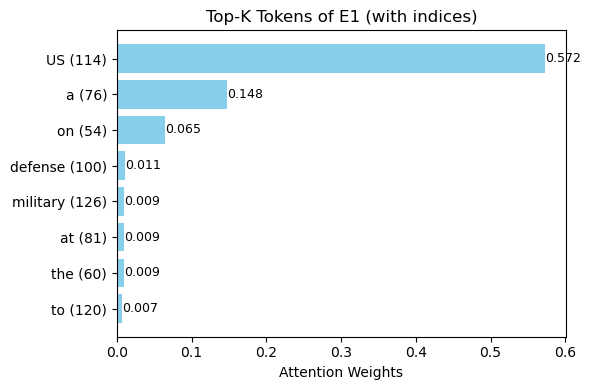

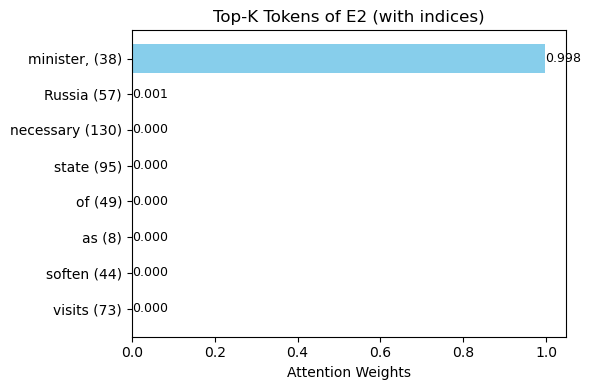

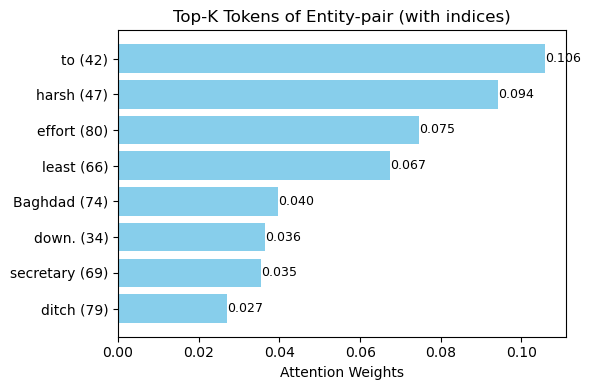

In [38]:
show_top_k_by_idx_pair(test_df_no_vague, context_tokens_no_vague, all_labels, all_predictions, 285, batch_size)

In [ ]:
df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_D4A.json")

In [ ]:
id2label = {v:k for k, v in label_mapping.items()}

In [ ]:
# df_expanded = add_is_intra_batch(train_df, batch_size=64)
test_df_no_vague = test_df[test_df["label"] != "VAGUE"]
test_df_no_vague = test_df_no_vague.reset_index(drop=True)
df_expanded = add_is_intra_batch(test_df_no_vague, spacy_nlp, batch_size=64)

In [ ]:
d4A = build_analysis_dataset(all_labels,
                             all_predictions,
                             logs,
                             id2label,
                             entity_pairs=df_expanded.values.tolist(),
                             vocab=spacy_nlp.vocab)  # giúp decode id → string)

In [ ]:
# Write dictionary to JSON file
with open("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/data4analyze.json", "w") as json_file:
    json.dump(d4A, json_file, indent=4)

In [ ]:
df_analysis = create_analysis_dataframe(d4A)

In [ ]:
# df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/train_D4A.json")
df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_D4A.json")


In [6]:
# df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/train_D4A.json")
df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/test_D4A.json")

POS distribution per entity_type:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.074303  0.117395  0.033112  0.055767  0.021388  0.102503   
e2           0.090621  0.119613  0.029626  0.053074  0.028200  0.086343   
pair         0.085393  0.118346  0.028200  0.050063  0.027883  0.087294   

pos              INTJ      NOUN       NUM      PART      PRON     PROPN  \
entity_type                                                               
e1           0.000317  0.200729  0.030418  0.029468  0.038973  0.123574   
e2           0.000000  0.206432  0.040558  0.022814  0.036280  0.133555   
pair         0.000634  0.203422  0.039607  0.023764  0.037706  0.139100   

pos             PUNCT     SCONJ       SYM      VERB         X  
entity_type                                                    
e1           0.024715  0.021071  0.001743  0.122307  0.002218  
e2           0.019011 

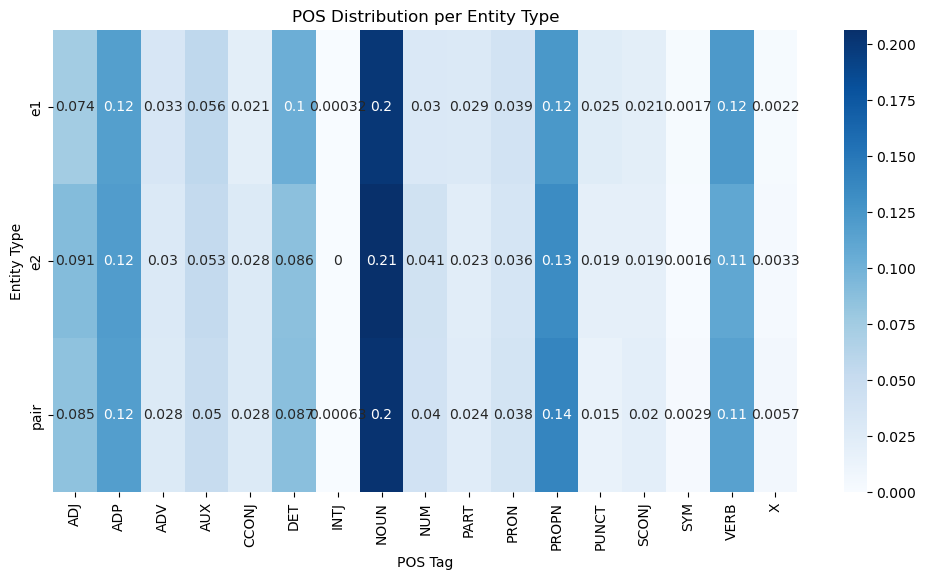

In [7]:
pos_distribution(df_analysis)

Dependency distribution per entity_type:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.021229  0.007921  0.004594  0.023131  0.039607  0.001901   
e2           0.018695  0.005862  0.006812  0.018536  0.036280  0.003802   
pair         0.026141  0.006971  0.004436  0.017427  0.032003  0.002218   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.068758  0.010298  0.002693  0.053866  ...   0.000317  0.007129   
e2           0.086027  0.008555  0.004119  0.048638  ...   0.000951  0.004594   
pair         0.084759  0.005070  0.003961  0.044677  ...   0.000475  0.004278   

dep              pobj      poss      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.098542  0.00

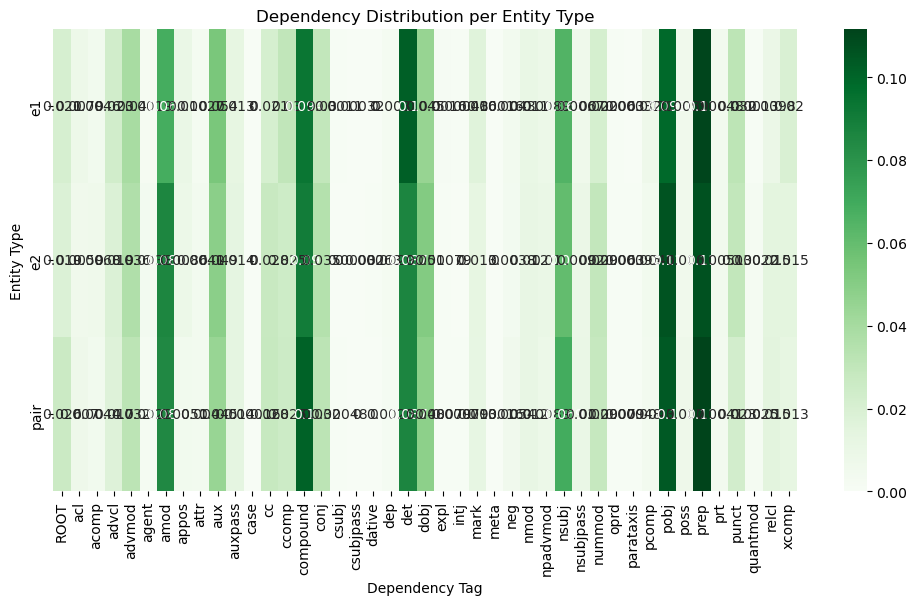

In [8]:
dep_distribution(df_analysis)

Morphology distribution per entity_type:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.215621                              0.021863   
e2           0.201204                              0.029626   
pair         0.203897                              0.026299   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.016318   
e2                                       0.015843   
pair                                     0.016160   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000317        
e2                                                    0.000158        
pair                                                  0.000792        

morph        Case=Acc

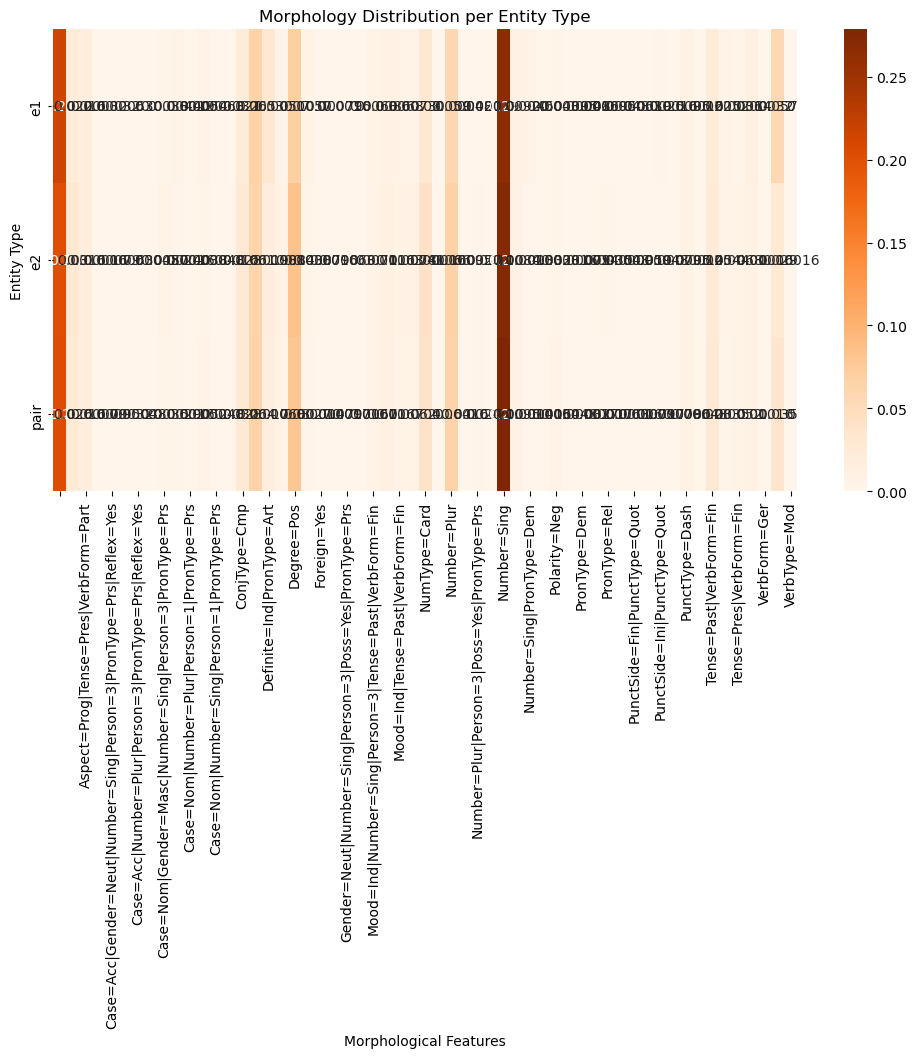

In [9]:
morph_distribution(df_analysis)

Số cặp với prediction đúng: 15744

=== Relation: BEFORE ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.073782  0.122851  0.031877  0.049785  0.022564  0.102436   
e2           0.095630  0.122493  0.022564  0.055516  0.032235  0.072350   
pair         0.087751  0.113897  0.030444  0.049427  0.024713  0.093123   

pos              INTJ      NOUN       NUM      PART      PRON     PROPN  \
entity_type                                                               
e1           0.000716  0.196991  0.026504  0.029011  0.041189  0.128582   
e2           0.000000  0.209885  0.046920  0.022564  0.035100  0.130731   
pair         0.001074  0.217765  0.028295  0.027221  0.041189  0.128223   

pos             PUNCT     SCONJ       SYM      VERB         X  
entity_type                                                    
e1           0.031519  0.020057  0.001791 

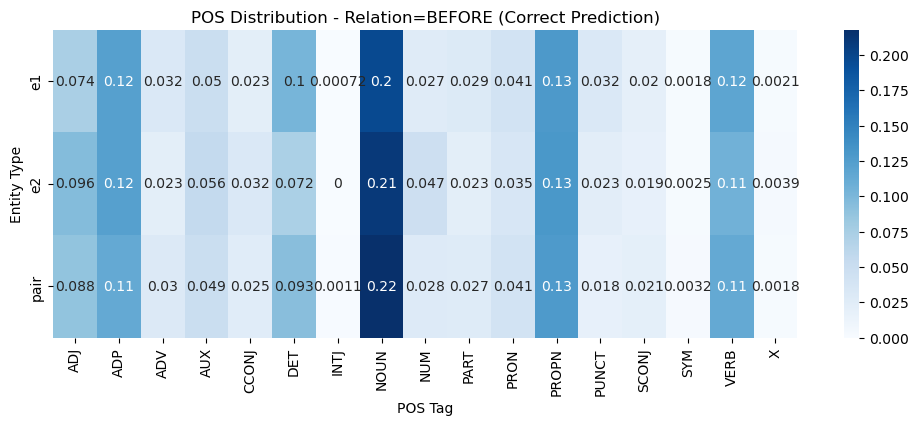

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.022564  0.008954  0.005372  0.019699  0.035817  0.001433   
e2           0.017908  0.005372  0.008596  0.015759  0.030086  0.003223   
pair         0.016834  0.006089  0.005372  0.016117  0.032951  0.002507   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.071275  0.013968  0.002149  0.047278  ...   0.000000  0.006805   
e2           0.089542  0.009312  0.006447  0.046203  ...   0.001074  0.005372   
pair         0.080229  0.007163  0.005014  0.048711  ...   0.000716  0.005014   

dep              pobj      poss      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.092049  0.005372  0.114971  

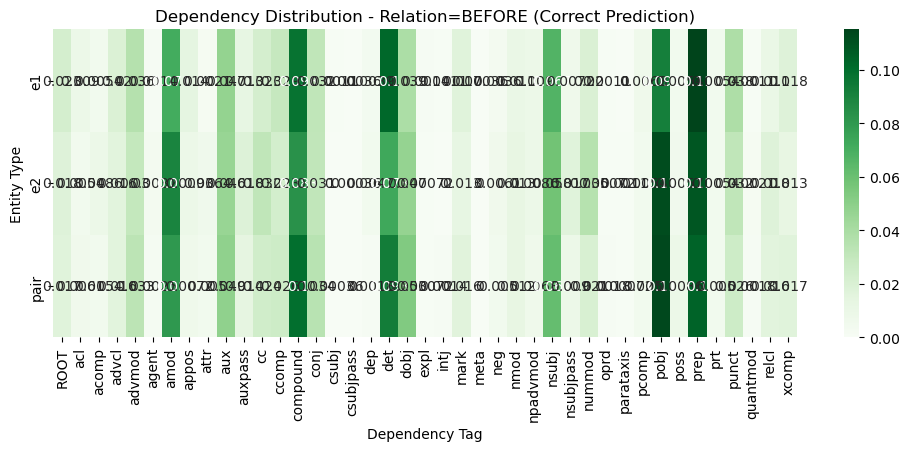

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.222779                              0.022206   
e2           0.195917                              0.037966   
pair         0.201648                              0.023639   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.015401   
e2                                       0.012536   
pair                                     0.013252   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000358        
e2                                                    0.000000        
pair                                                  0.000716        

morph        Case=Acc|Gender=Neut|Num

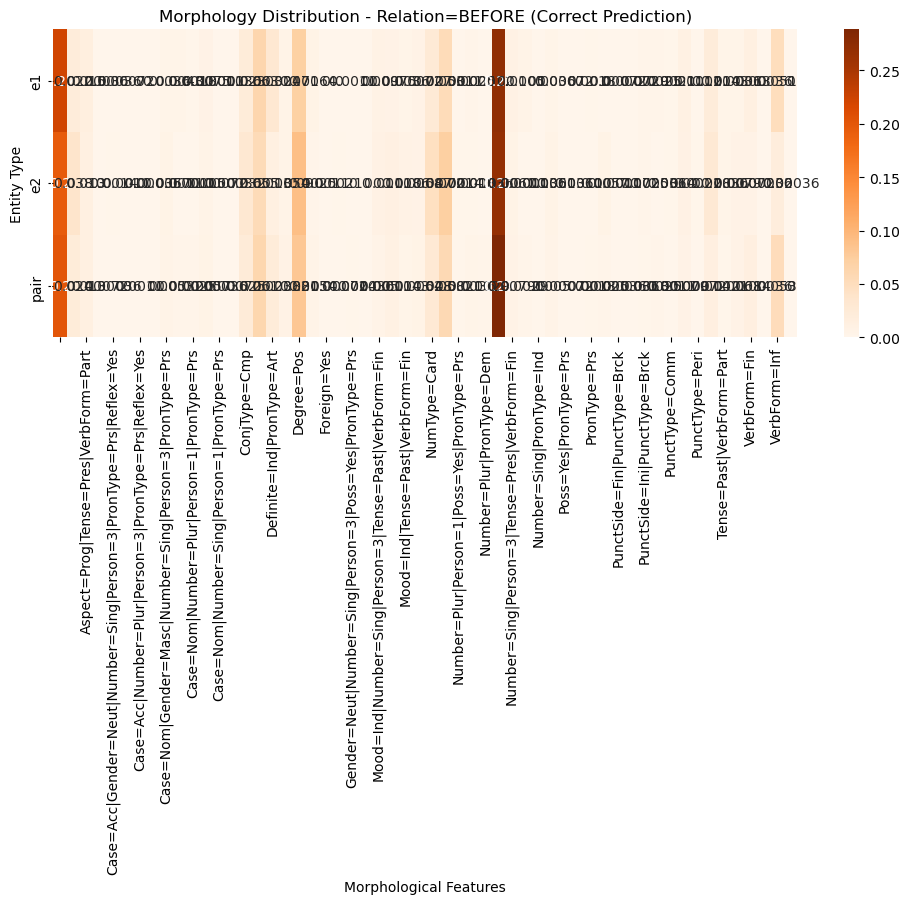


=== Relation: AFTER ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.074786  0.113782  0.030449  0.055556  0.021902  0.104701   
e2           0.086004  0.114850  0.040598  0.040598  0.028312  0.104167   
pair         0.080128  0.110043  0.024573  0.048077  0.030449  0.089744   

pos              INTJ      NOUN       NUM      PART      PRON     PROPN  \
entity_type                                                               
e1           0.000000  0.214744  0.034188  0.035791  0.032051  0.120192   
e2           0.000000  0.199786  0.040598  0.027244  0.035256  0.132479   
pair         0.000534  0.189637  0.058761  0.020299  0.034722  0.152778   

pos             PUNCT     SCONJ       SYM      VERB         X  
entity_type                                                    
e1           0.017628  0.016560  0.001068  0.126603  0.000000  
e2           

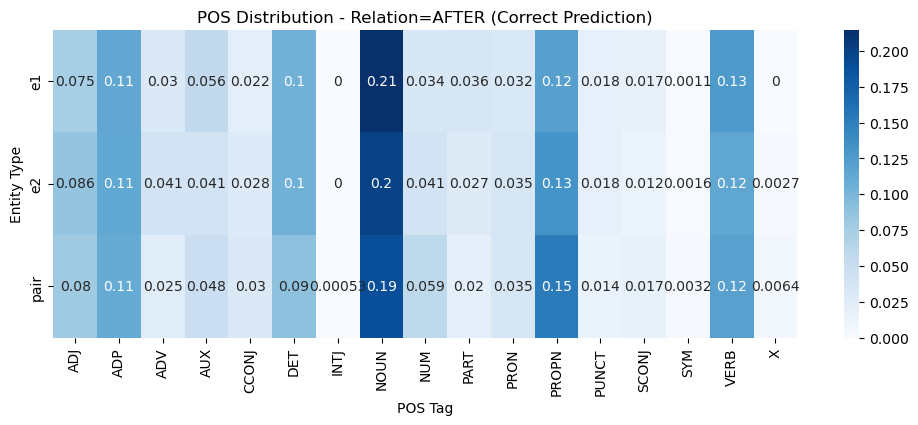

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.017094  0.007479  0.003205  0.028846  0.036325  0.002671   
e2           0.016560  0.005876  0.002137  0.017628  0.041132  0.002137   
pair         0.034722  0.008547  0.002137  0.016560  0.031517  0.003739   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.066774  0.006410  0.002671  0.061966  ...   0.000534  0.005342   
e2           0.085470  0.008013  0.001603  0.051282  ...   0.000000  0.003739   
pair         0.091346  0.004808  0.002671  0.042201  ...   0.000000  0.003205   

dep              pobj      poss      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.106303  0.004274  0.108440  

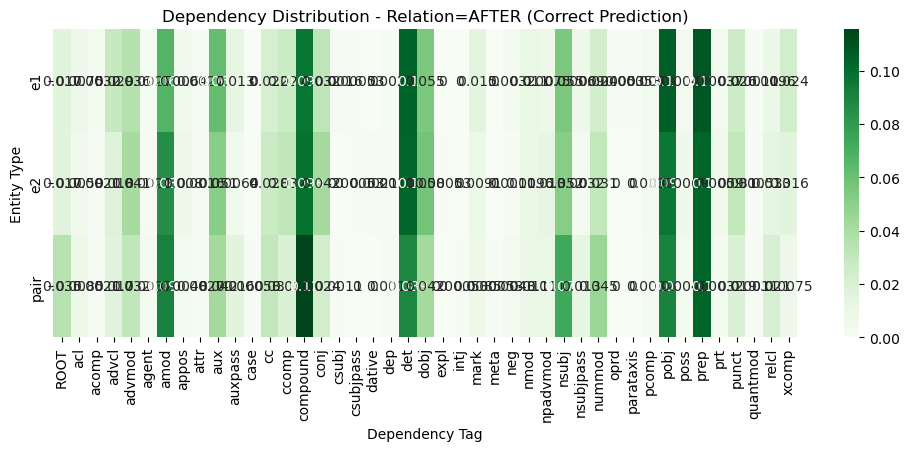

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.204060                              0.019765   
e2           0.205128                              0.021902   
pair         0.192308                              0.035791   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.014957   
e2                                       0.016026   
pair                                     0.020299   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.000534        
pair                                                  0.001068        

morph        Case=Acc|Gender=Neut|Num

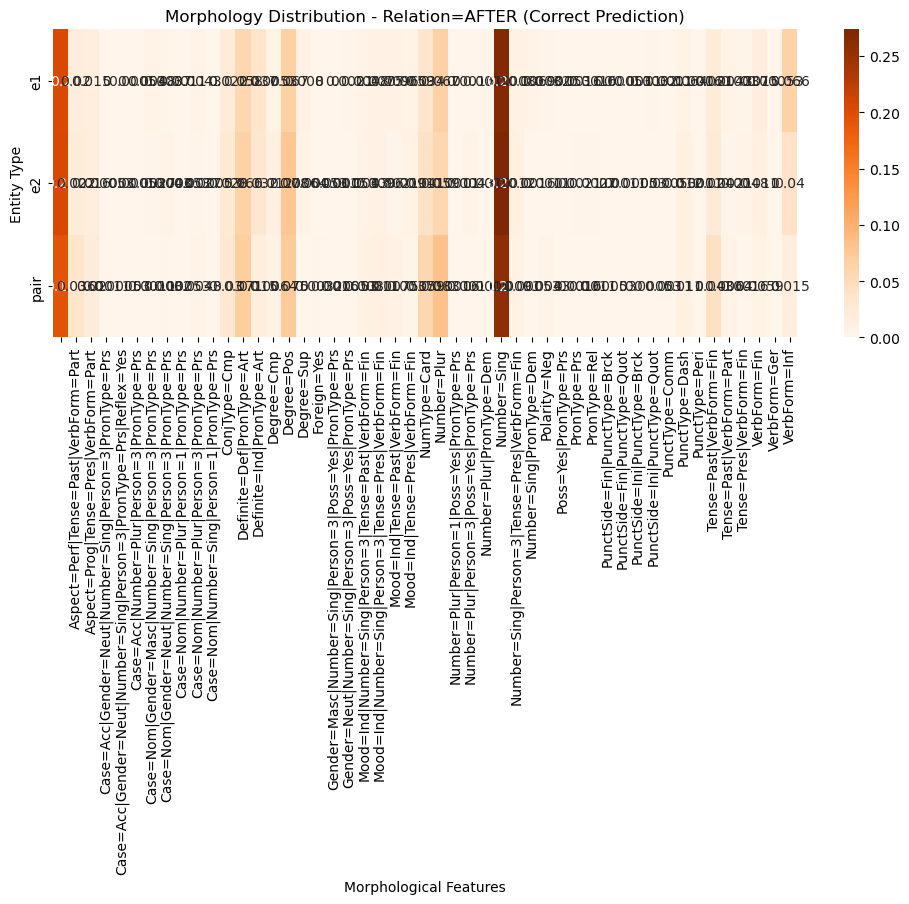


=== Relation: INCLUDES ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.066667  0.095833  0.016667  0.058333  0.029167  0.091667   
e2           0.062500  0.129167  0.012500  0.066667  0.025000  0.091667   
pair         0.070833  0.125000  0.020833  0.091667  0.033333  0.054167   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.166667  0.054167  0.008333  0.054167  0.145833  0.012500   
e2           0.200000  0.033333  0.008333  0.062500  0.129167  0.004167   
pair         0.170833  0.050000  0.008333  0.029167  0.170833  0.000000   

pos             SCONJ      VERB         X  
entity_type                                
e1           0.050000  0.141667  0.008333  
e2           0.045833  0.129167  0.000000  
pair         0.033333  0.1

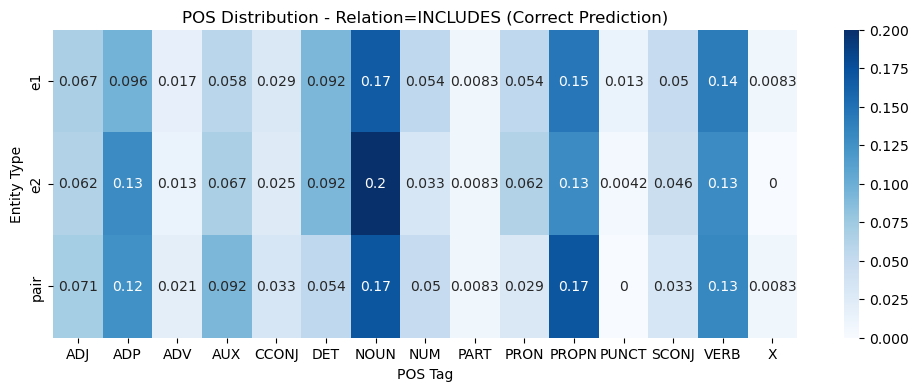

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.037500  0.000000  0.000000  0.016667  0.041667  0.004167   
e2           0.004167  0.008333  0.008333  0.012500  0.037500  0.016667   
pair         0.033333  0.004167  0.000000  0.029167  0.025000  0.000000   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.070833  0.008333  0.004167  0.029167  ...   0.000000  0.012500   
e2           0.062500  0.004167  0.016667  0.037500  ...   0.004167  0.016667   
pair         0.070833  0.000000  0.008333  0.058333  ...   0.000000  0.004167   

dep              pobj      poss      prep     prt     punct  quantmod  \
entity_type                                                             
e1           0.116667  0.004167  0.104167  0.00

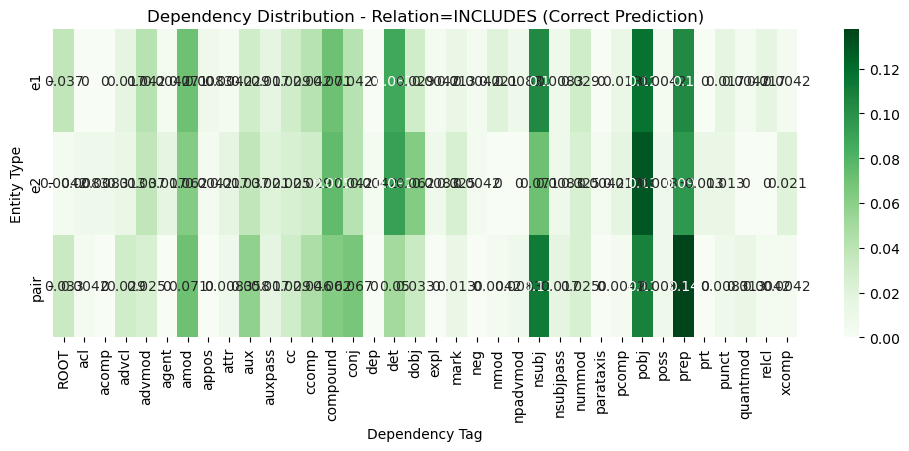

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.208333                              0.025000   
e2           0.220833                              0.033333   
pair         0.195833                              0.025000   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.016667   
e2                                       0.033333   
pair                                     0.012500   

morph        Case=Acc|Number=Plur|Person=3|PronType=Prs  \
entity_type                                               
e1                                             0.004167   
e2                                             0.000000   
pair                                           0.000000   

morph        Case=Nom|Gender=Masc|Number=Sing|Person=3|PronType=Prs  \
entity_type               

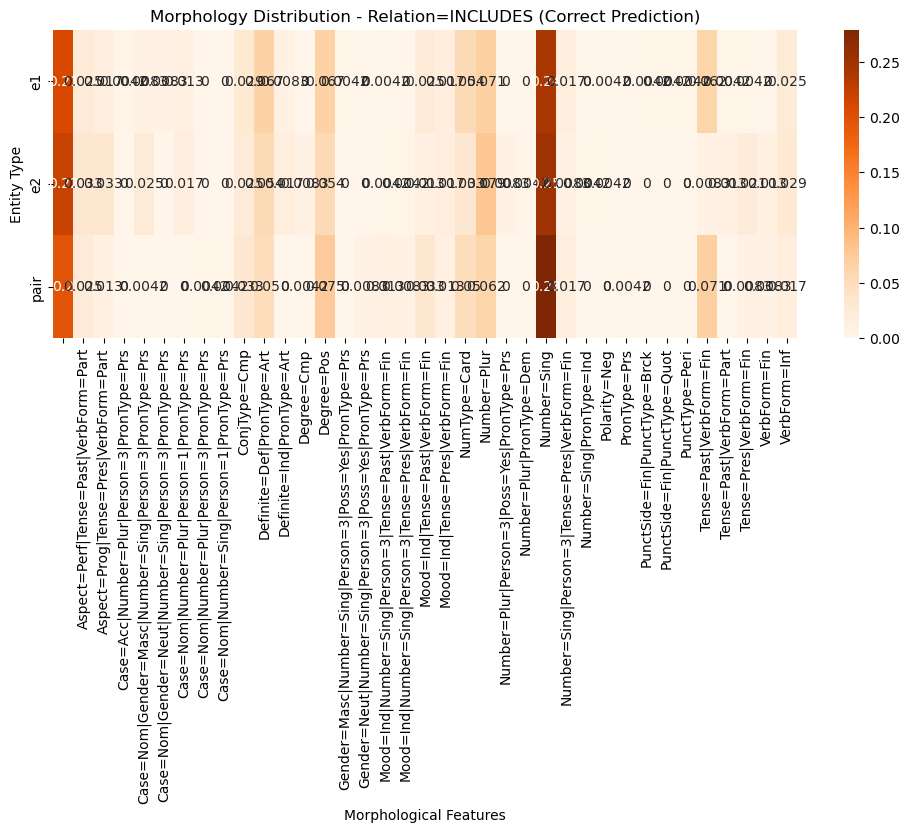


=== Relation: SIMULTANEOUS ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.078125  0.109375  0.031250  0.046875  0.015625  0.031250   
e2           0.125000  0.093750  0.046875  0.093750  0.015625  0.046875   
pair         0.078125  0.140625  0.046875  0.078125  0.062500  0.031250   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.281250  0.031250  0.000000  0.078125  0.109375  0.031250   
e2           0.187500  0.015625  0.015625  0.062500  0.187500  0.015625   
pair         0.171875  0.046875  0.000000  0.031250  0.156250  0.000000   

pos             SCONJ      VERB         X  
entity_type                                
e1           0.046875  0.093750  0.015625  
e2           0.046875  0.046875  0.000000  
pair         0.031250 

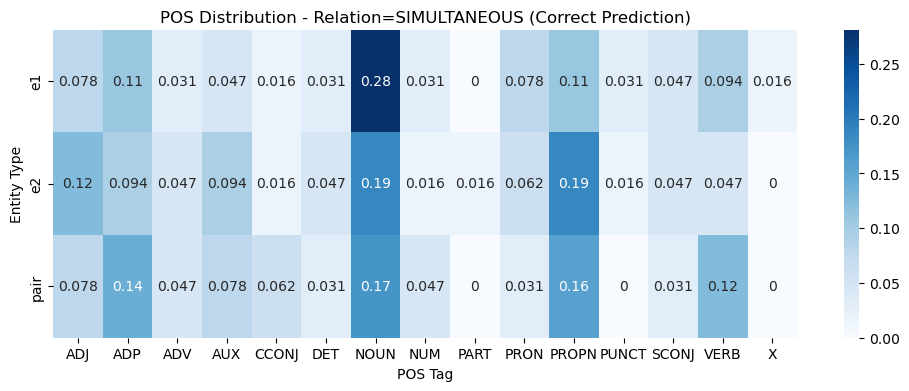

Dependency distribution:
dep             ROOT     advcl    advmod     agent      amod     appos  \
entity_type                                                              
e1           0.03125  0.000000  0.078125  0.000000  0.046875  0.015625   
e2           0.00000  0.015625  0.046875  0.015625  0.140625  0.000000   
pair         0.06250  0.015625  0.046875  0.000000  0.062500  0.015625   

dep               aux   auxpass        cc    ccomp  ...      nmod  npadvmod  \
entity_type                                         ...                       
e1           0.015625  0.015625  0.015625  0.03125  ...  0.031250  0.015625   
e2           0.046875  0.046875  0.015625  0.03125  ...  0.000000  0.000000   
pair         0.046875  0.031250  0.062500  0.00000  ...  0.046875  0.000000   

dep             nsubj  nsubjpass    nummod      pobj      prep     punct  \
entity_type                                                                
e1           0.140625   0.015625  0.000000  0.109375  0.

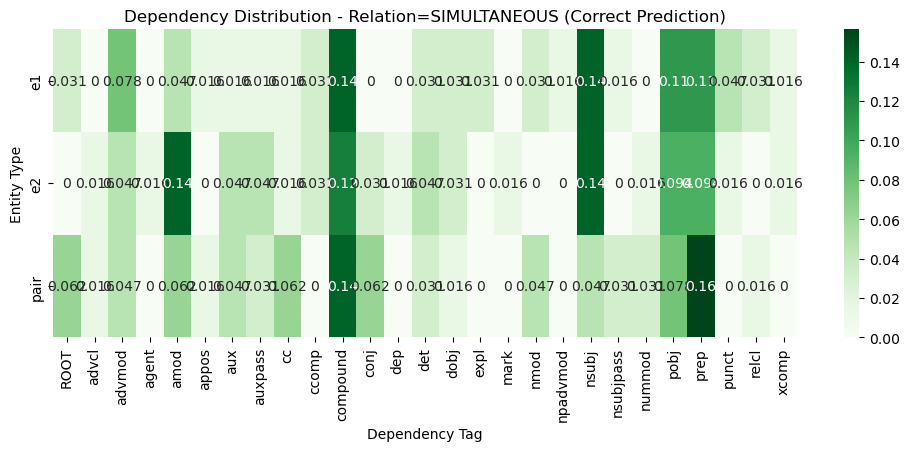

Morphology distribution:
morph                 Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                  
e1           0.25000                              0.015625   
e2           0.18750                              0.000000   
pair         0.21875                              0.031250   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.000000   
e2                                       0.015625   
pair                                     0.000000   

morph        Case=Nom|Gender=Masc|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                    0.000000        
e2                                                    0.015625        
pair                                                  0.000000        

morph        Case=Nom|Gender=Neut|Number=S

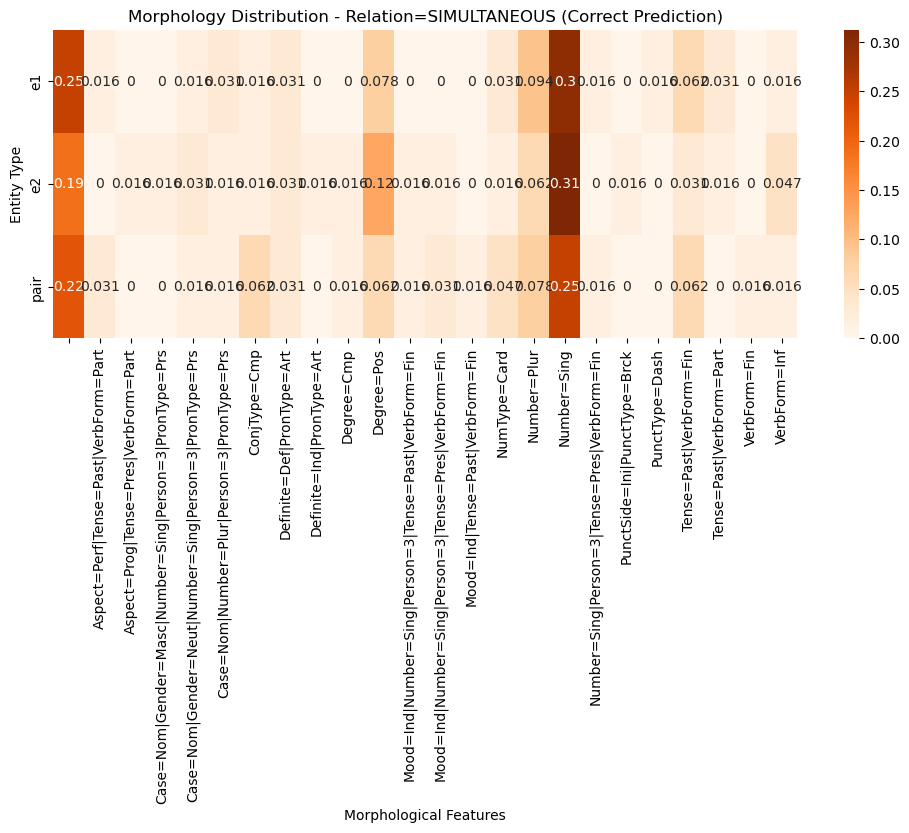


=== Relation: IS_INCLUDED ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.092857  0.078571  0.042857  0.103571  0.017857  0.096429   
e2           0.085714  0.121429  0.028571  0.064286  0.028571  0.100000   
pair         0.075000  0.132143  0.021429  0.064286  0.014286  0.089286   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.214286  0.010714  0.035714  0.042857  0.089286  0.021429   
e2           0.178571  0.025000  0.021429  0.032143  0.139286  0.007143   
pair         0.203571  0.025000  0.042857  0.025000  0.142857  0.007143   

pos             SCONJ      VERB         X  
entity_type                                
e1           0.021429  0.128571  0.003571  
e2           0.039286  0.114286  0.014286  
pair         0.028571  

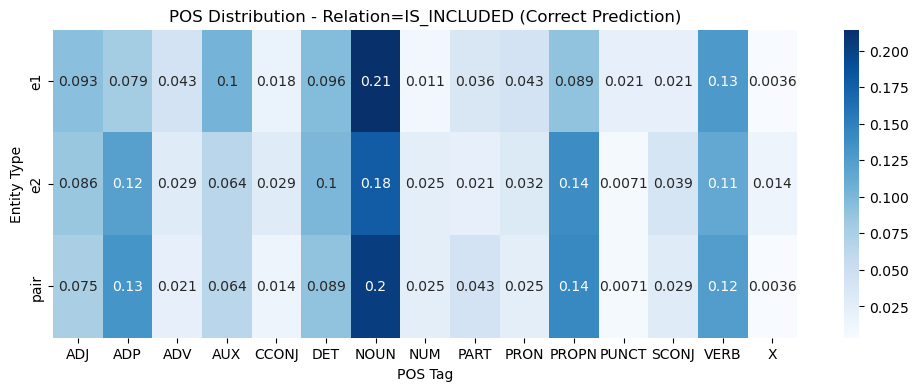

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.017857  0.007143  0.003571  0.025000  0.053571  0.003571   
e2           0.025000  0.007143  0.014286  0.042857  0.046429  0.003571   
pair         0.028571  0.014286  0.010714  0.021429  0.025000  0.000000   

dep              amod     appos      attr       aux  ...  parataxis     pcomp  \
entity_type                                          ...                        
e1           0.089286  0.007143  0.003571  0.096429  ...   0.003571  0.010714   
e2           0.078571  0.003571  0.000000  0.050000  ...   0.000000  0.003571   
pair         0.078571  0.000000  0.003571  0.046429  ...   0.000000  0.000000   

dep              pobj      poss      prep       prt  punct  quantmod  \
entity_type                                                            
e1           0.085714  0.007143  0.071429  0.0035

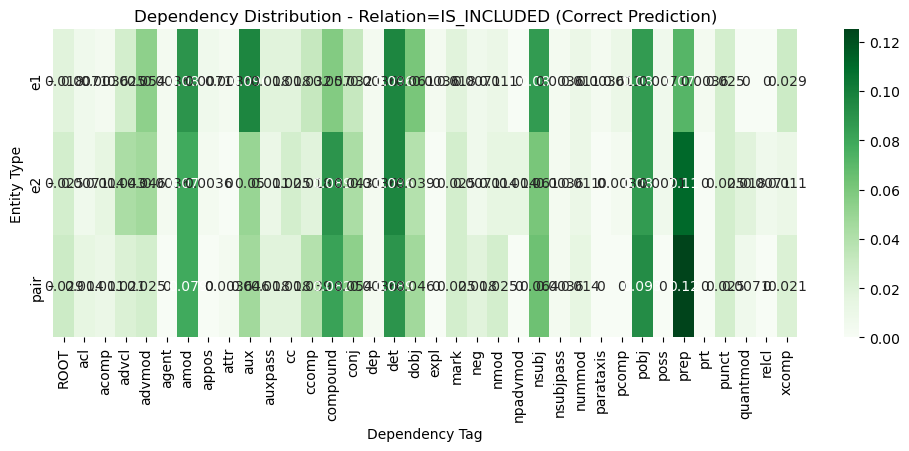

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.178571                              0.021429   
e2           0.232143                              0.017857   
pair         0.210714                              0.042857   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.021429   
e2                                       0.025000   
pair                                     0.017857   

morph        Case=Acc|Gender=Neut|Number=Sing|Person=3|PronType=Prs|Reflex=Yes  \
entity_type                                                                      
e1                                                    0.000000                   
e2                                                    0.003571                   
pair                                                  0.000000   

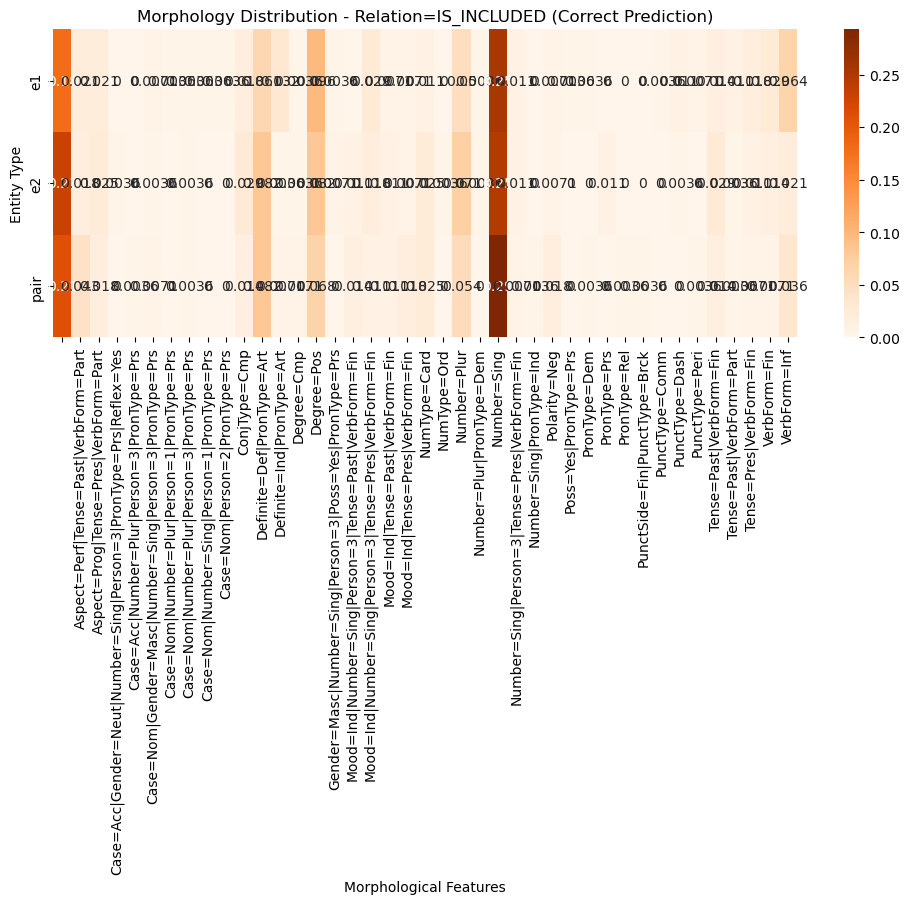

In [10]:
analyze_pos_dep_morph_by_relation(df_analysis)